In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
train_data = pd.read_csv('dataset/train.csv')
filtered_train_data = train_data.drop(['secondary_labels', 'type', 'filename', 'url', 'author', 'license'], axis=1).copy()
filtered_train_data

,primary_label,collection,rating,latitude,longitude,scientific_name,common_name
0,1139490,CSA,0.0,7.3206,-73.7128,Ragoniella pulchella,Ragoniella pulchella
1,1139490,CSA,0.0,7.3206,-73.7128,Ragoniella pulchella,Ragoniella pulchella
2,1192948,CSA,0.0,7.3791,-73.7313,Oxyprora surinamensis,Oxyprora surinamensis
3,1192948,CSA,0.0,7.2800,-73.8582,Oxyprora surinamensis,Oxyprora surinamensis
4,1192948,CSA,0.0,7.3791,-73.7313,Oxyprora surinamensis,Oxyprora surinamensis
...,...,...,...,...,...,...,...
28559,ywcpar,iNat,0.0,7.6921,-80.3379,Amazona ochrocephala,Yellow-crowned Parrot
28560,ywcpar,iNat,0.0,8.9918,-79.4877,Amazona ochrocephala,Yellow-crowned Parrot
28561,ywcpar,iNat,0.0,9.2316,-70.2041,Amazona ochrocephala,Yellow-crowned Parrot
28562,ywcpar,iNat,0.0,10.5838,-66.8545,Amazona ochrocephala,Yellow-crowned Parrot


In [ ]:
taxonomy_data = pd.read_csv('dataset/taxonomy.csv')
filtered_taxonomy_data = taxonomy_data[['primary_label', 'inat_taxon_id', 'class_name']]

filtered_train_data = filtered_train_data.merge(filtered_taxonomy_data, left_on='primary_label', right_on='primary_label')
filtered_train_data

,primary_label,collection,rating,latitude,longitude,scientific_name,common_name,inat_taxon_id,class_name
0,1139490,CSA,0.0,7.3206,-73.7128,Ragoniella pulchella,Ragoniella pulchella,1139490,Insecta
1,1139490,CSA,0.0,7.3206,-73.7128,Ragoniella pulchella,Ragoniella pulchella,1139490,Insecta
2,1192948,CSA,0.0,7.3791,-73.7313,Oxyprora surinamensis,Oxyprora surinamensis,1192948,Insecta
3,1192948,CSA,0.0,7.2800,-73.8582,Oxyprora surinamensis,Oxyprora surinamensis,1192948,Insecta
4,1192948,CSA,0.0,7.3791,-73.7313,Oxyprora surinamensis,Oxyprora surinamensis,1192948,Insecta
...,...,...,...,...,...,...,...,...,...
28559,ywcpar,iNat,0.0,7.6921,-80.3379,Amazona ochrocephala,Yellow-crowned Parrot,19003,Aves
28560,ywcpar,iNat,0.0,8.9918,-79.4877,Amazona ochrocephala,Yellow-crowned Parrot,19003,Aves
28561,ywcpar,iNat,0.0,9.2316,-70.2041,Amazona ochrocephala,Yellow-crowned Parrot,19003,Aves
28562,ywcpar,iNat,0.0,10.5838,-66.8545,Amazona ochrocephala,Yellow-crowned Parrot,19003,Aves


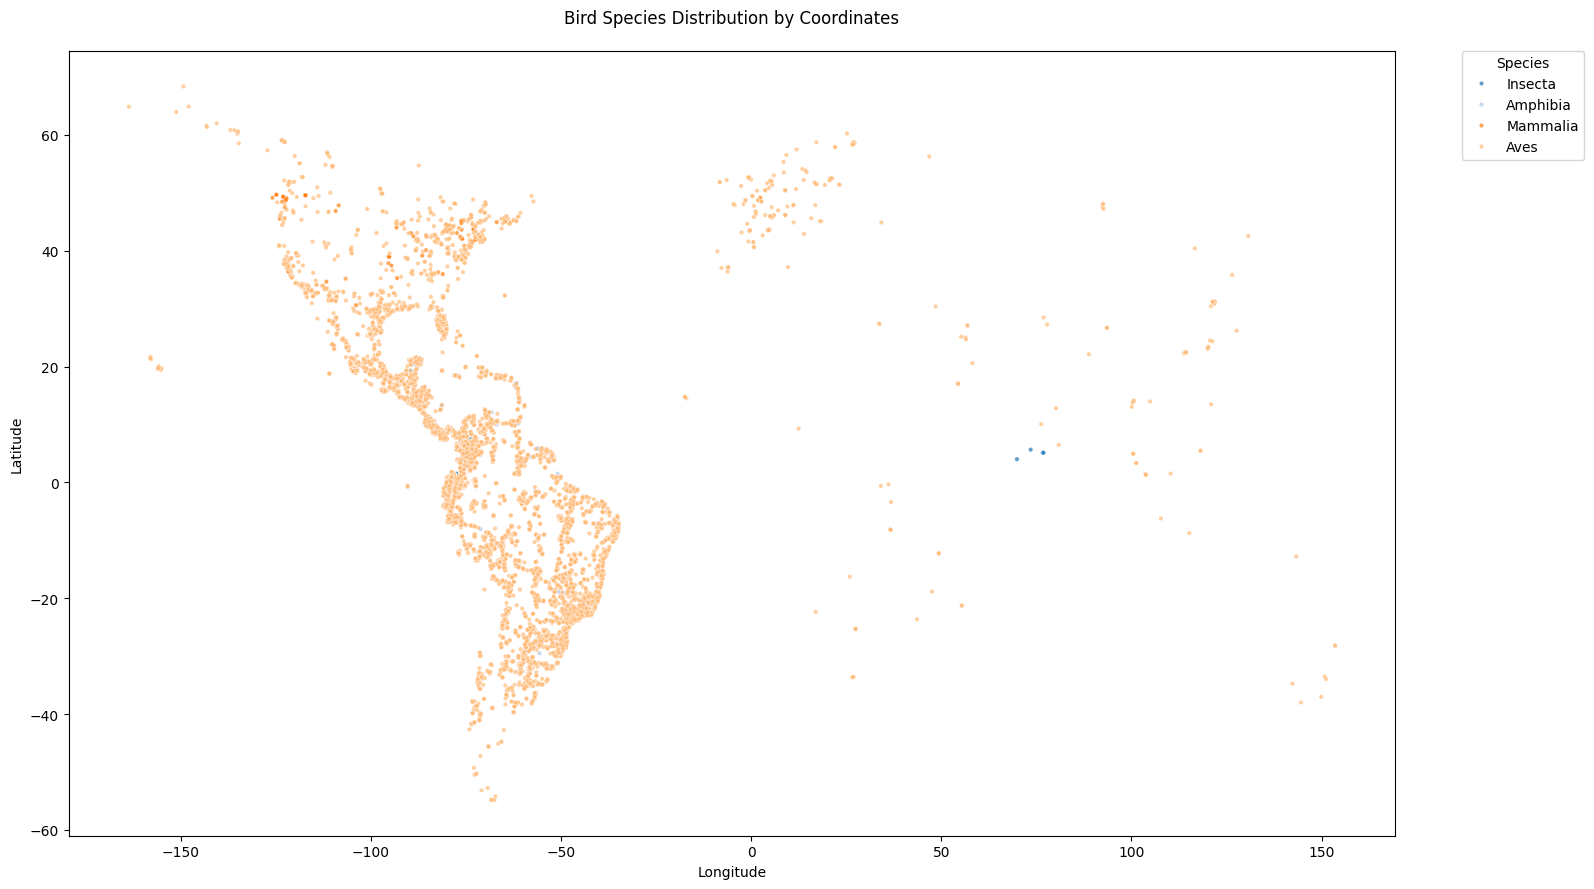

In [ ]:
df = filtered_train_data.dropna(subset=['latitude', 'longitude'])

plt.figure(figsize=(16, 9))

ax = sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='class_name',
    palette='tab20',
    alpha=0.7,
    s=10
)

plt.legend(
    title='Species',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0
)

ax.set_title('Species Distribution by Coordinates', pad=20)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

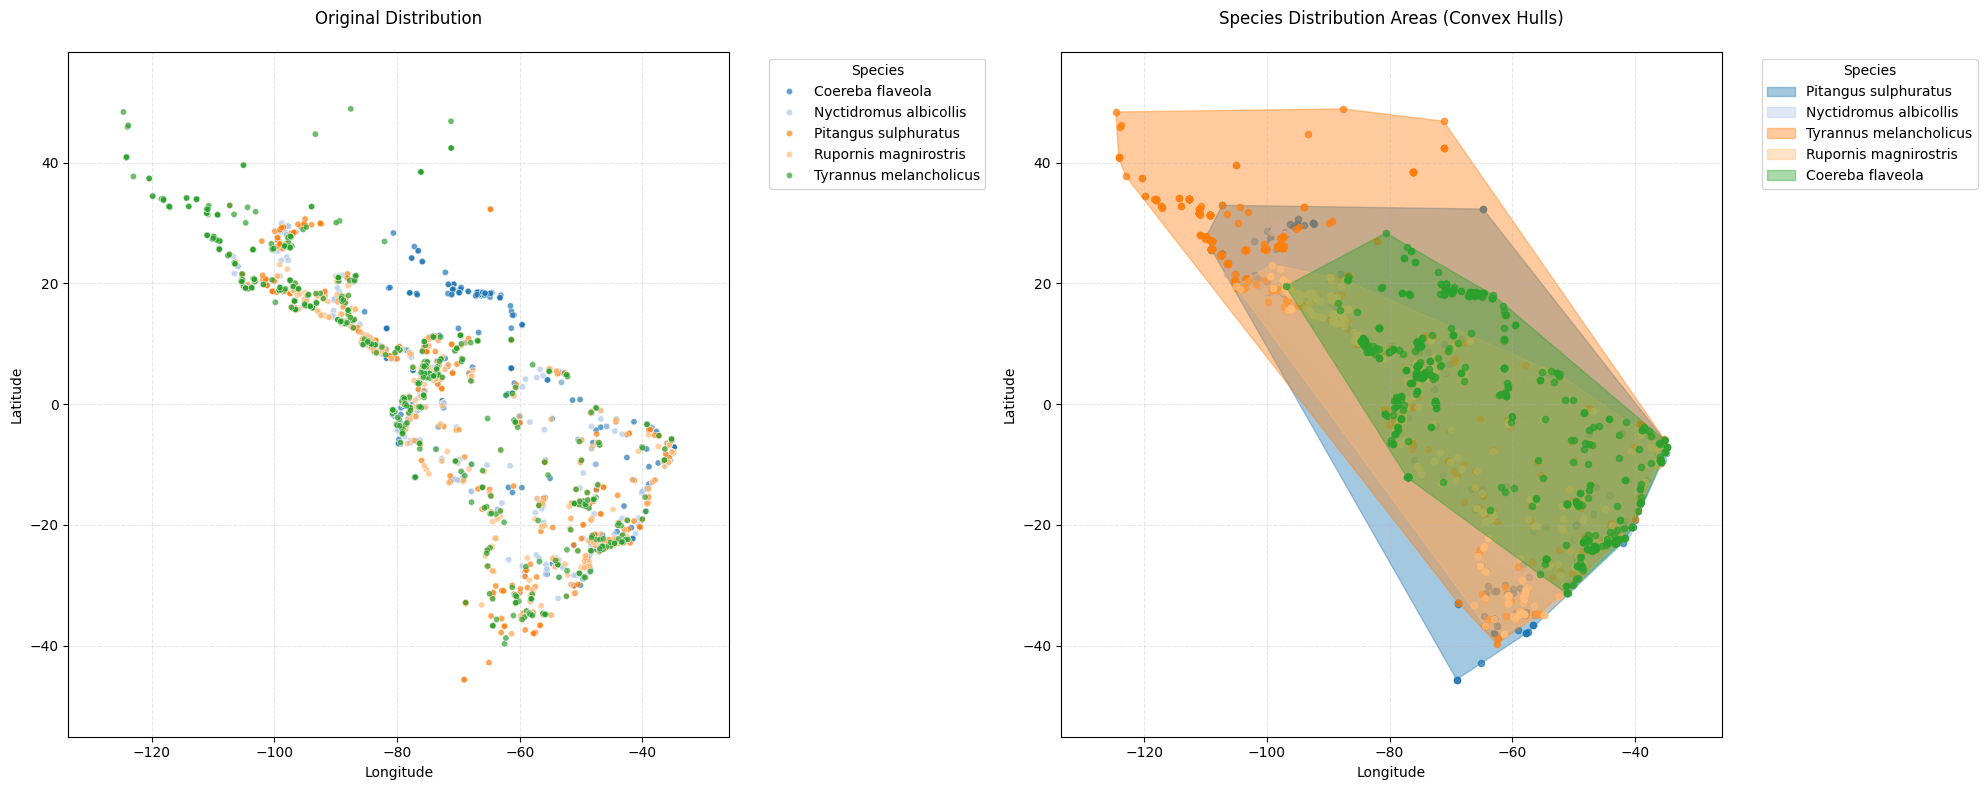

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.spatial import ConvexHull

# Filter and prepare data
df = filtered_train_data.dropna(subset=['latitude', 'longitude'])
df = df[df['class_name'] == 'Aves']
top_species = df['scientific_name'].value_counts().head(5).index
df = df[df['scientific_name'].isin(top_species)]

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), facecolor='white')

# Original scatter plot (left)
sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='scientific_name',
    palette='tab20',
    alpha=0.7,
    s=20,
    ax=ax1
)
ax1.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.set_title('Original Distribution', pad=20)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')

# Convex hull plot (right)
palette = sns.color_palette('tab20', n_colors=len(top_species))

for i, species in enumerate(top_species):
    species_df = df[df['scientific_name'] == species]
    points = species_df[['longitude', 'latitude']].values
    
    # Only compute hull if we have enough points
    if len(points) >= 3:
        hull = ConvexHull(points)
        
        # Plot the convex hull polygon
        poly = plt.Polygon(
            points[hull.vertices],
            color=palette[i],
            alpha=0.4,
            label=species
        )
        ax2.add_patch(poly)
        
        # Plot the original points
        ax2.scatter(
            points[:, 0],
            points[:, 1],
            color=palette[i],
            alpha=0.7,
            s=20
        )

# Set equal aspect and labels
ax2.set_title('Species Distribution Areas (Convex Hulls)', pad=20)
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')

# Set consistent axis limits between plots
x_min, x_max = df['longitude'].min(), df['longitude'].max()
y_min, y_max = df['latitude'].min(), df['latitude'].max()
x_buffer = (x_max - x_min) * 0.1
y_buffer = (y_max - y_min) * 0.1

for ax in [ax1, ax2]:
    ax.set_xlim(x_min - x_buffer, x_max + x_buffer)
    ax.set_ylim(y_min - y_buffer, y_max + y_buffer)
    ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()